# Phase 6 — Per-query failure analysis

Reproducible walkthrough for the Phase 6 deliverable. Everything this
notebook does is also implemented in the four `scripts/phase6_*.py` driver
scripts — they are the canonical entry points. The notebook exists so a
reviewer can read the analysis top-to-bottom without re-running anything.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from vitruvius.analysis.error_analysis import (
    DEFAULT_DATASETS,
    DEFAULT_ENCODERS,
    ENCODER_FAMILY,
    FAILURE_THRESHOLD,
    SUCCESS_THRESHOLD,
    decode_parquet_columns,
    load_query_frame,
)

OUT = Path("../experiments/phase6")
FIG = Path("../figures")
sns.set_context("notebook")
sns.set_style("whitegrid")

## 1. Gate check

Every one of the 18 bench JSONs must contain a `per_query_results` payload
with the four required keys. If this cell raises, stop and surface to the
operator — the information is not recoverable from aggregate metrics.

In [2]:
required = {"nDCG@10", "ranked_doc_ids", "relevance_judgments", "query_text"}
for pct_dir, encs in [
    ("../experiments/phase3", ["minilm-l6-v2", "bert-base", "gte-small"]),
    ("../experiments/phase5/bench", ["lstm-retriever", "conv-retriever", "mamba-retriever-fs"]),
]:
    for enc in encs:
        for ds in DEFAULT_DATASETS:
            p = Path(pct_dir) / f"{enc}__{ds}.json"
            d = json.load(p.open())
            pq = d["per_query_results"]
            first = pq[next(iter(pq))]
            missing = required - set(first.keys())
            assert not missing, f"{p}: missing {missing}"
print("gate check: PASS — 18 cells, full per-query schema present.")

gate check: PASS — 18 cells, full per-query schema present.


## 2. Load the query-level frame

`load_query_frame` produces one row per (encoder, dataset, query) with
metrics, features, and the full ranked-list + qrels. 7,626 rows expected
(323 + 300 + 648 queries × 6 encoders).

In [3]:
df = decode_parquet_columns(pd.read_parquet(OUT / "query_frame.parquet"))
print("rows:", len(df))
df.head(3)

rows: 7626


,encoder,encoder_family,dataset,query_id,query_text,query_length_tokens,query_length_chars,nDCG@10,hit@10,Recall@10,ranked_doc_ids,relevance_judgments,n_relevant_docs,top1_is_relevant,top3_is_relevant,is_failure,is_success
0,minilm-l6-v2,transformer,nfcorpus,PLAIN-1008,deafness,2,8,0.000000,False,0.000000,"[MED-901, MED-4668, MED-3863, MED-1519, MED-46...","{'MED-4532': 1, 'MED-4533': 1, 'MED-4534': 1, ...",5,False,False,True,False
1,minilm-l6-v2,transformer,nfcorpus,PLAIN-1018,DHA,2,3,0.168152,True,0.033333,"[MED-4322, MED-831, MED-4323, MED-5091, MED-43...","{'MED-1831': 1, 'MED-1832': 1, 'MED-1833': 1, ...",60,False,False,False,False
2,minilm-l6-v2,transformer,nfcorpus,PLAIN-102,Stopping Heart Disease in Childhood,5,35,0.192084,True,0.083333,"[MED-1548, MED-2590, MED-1949, MED-3255, MED-2...","{'MED-3253': 2, 'MED-3254': 2, 'MED-3255': 1, ...",24,False,False,False,False


Unit test: `n_relevant_docs` must be constant across encoders for the same
(dataset, query_id) — it is a property of the qrels, not the ranking.

In [4]:
assert (df.groupby(["dataset", "query_id"])["n_relevant_docs"].nunique() == 1).all()
print("n_relevant_docs invariance: OK")

n_relevant_docs invariance: OK


## 3. Zero-nDCG@10 rate grid

Extends Session 03's table with the transformer rates. Even pre-trained
transformers fail on 14–41% of queries out-of-distribution on BEIR — the
gap to from-scratch is large, not infinite.

In [5]:
zero_grid = pd.read_csv(OUT / "zero_ndcg_rates.csv", index_col=0)
(zero_grid * 100).round(1)

,nfcorpus,scifact,fiqa
encoder,,,
minilm-l6-v2,31.0,20.7,34.3
bert-base,32.8,26.7,40.9
gte-small,29.7,14.0,33.3
lstm-retriever,50.1,52.0,78.7
conv-retriever,58.5,73.7,90.4
mamba-retriever-fs,47.7,49.0,77.3


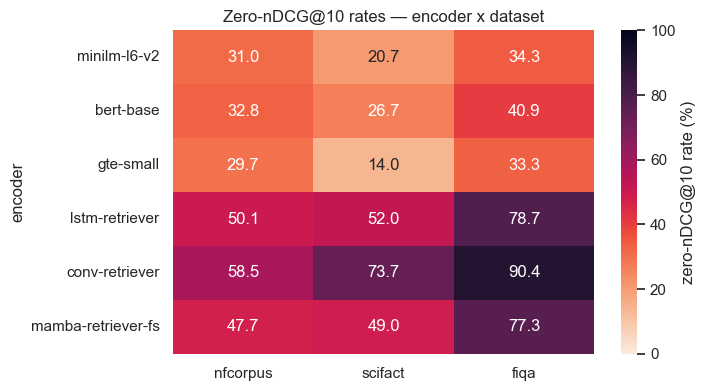

In [6]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
sns.heatmap(
    zero_grid * 100,
    annot=True,
    fmt=".1f",
    cmap="rocket_r",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "zero-nDCG@10 rate (%)"},
    ax=ax,
)
ax.set_title("Zero-nDCG@10 rates — encoder x dataset")
plt.show()

## 4. Cross-encoder agreement (Spearman ρ)

High within-family and moderate across-family agreement on nfcorpus;
transformer-vs-CNN ρ collapses to 0.24 on FiQA — the *pattern* of which
queries are easy/hard diverges on long natural-language questions.

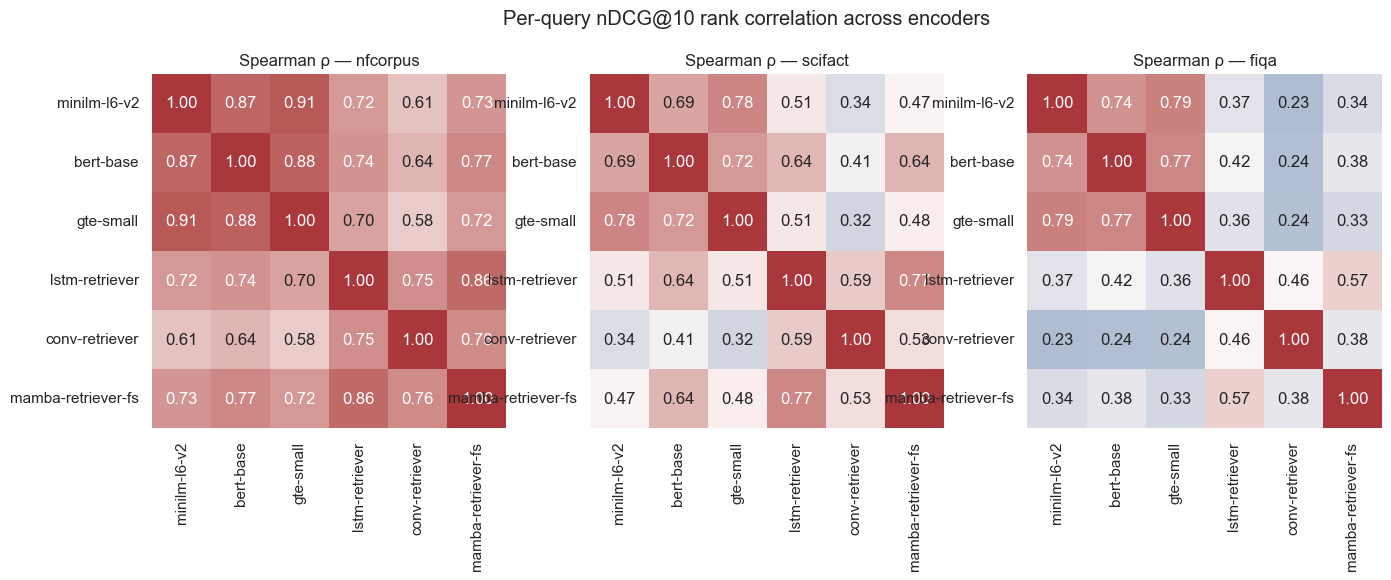

In [7]:
sp = {ds: pd.read_csv(OUT / f"spearman_{ds}.csv", index_col=0) for ds in DEFAULT_DATASETS}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, ds in zip(axes, DEFAULT_DATASETS):
    sns.heatmap(sp[ds], annot=True, fmt=".2f", cmap="vlag", vmin=-0.1, vmax=1.0,
                cbar=False, ax=ax, square=True)
    ax.set_title(f"Spearman ρ — {ds}")
fig.suptitle("Per-query nDCG@10 rank correlation across encoders", y=1.02)
plt.show()

## 5. Query length vs. retrieval quality

Quartile cutoffs differ per dataset (nfcorpus: q1=2, q3=7; scifact: q1=15,
q3=25; fiqa: q1=10, q3=17). Transformers are near-flat in length;
`conv-retriever` drops sharply on FiQA Q4 — the receptive-field hypothesis
confirmed.

In [8]:
pd.read_csv(OUT / "length_quartile_bounds.csv")

,dataset,q1,q2_median,q3,max
0,nfcorpus,2.0,4.0,7.0,26.0
1,scifact,15.0,19.0,25.0,62.0
2,fiqa,10.0,13.0,17.0,33.0


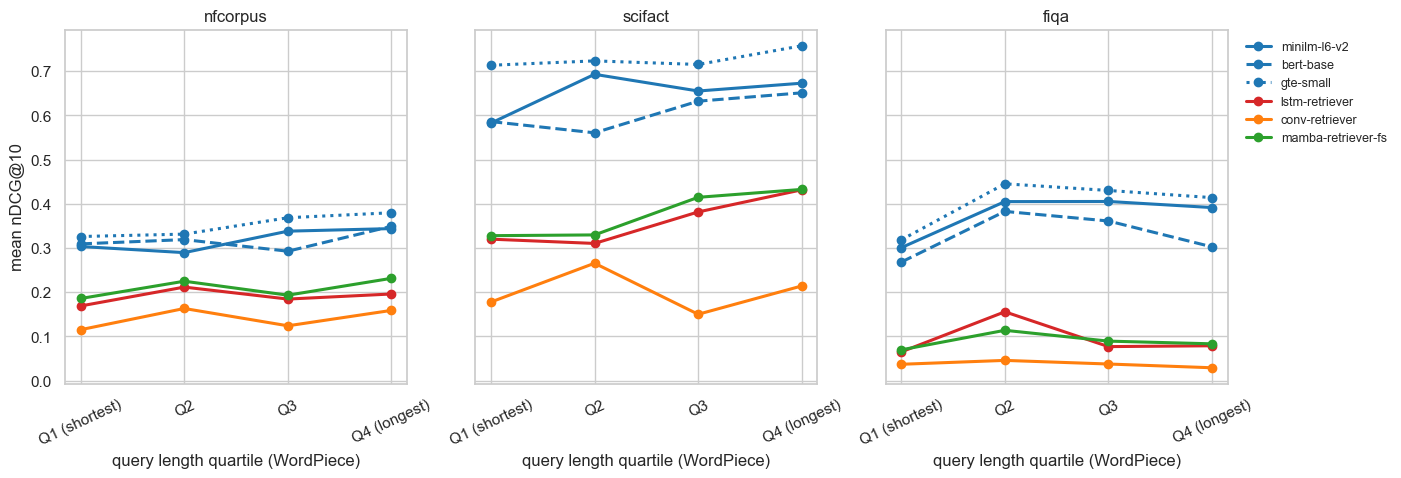

In [9]:
lb = pd.read_csv(OUT / "length_bins.csv")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
palette = {
    "minilm-l6-v2": "#1f77b4",
    "bert-base": "#1f77b4",
    "gte-small": "#1f77b4",
    "lstm-retriever": "#d62728",
    "conv-retriever": "#ff7f0e",
    "mamba-retriever-fs": "#2ca02c",
}
linestyle = {
    "minilm-l6-v2": "-",
    "bert-base": "--",
    "gte-small": ":",
    "lstm-retriever": "-",
    "conv-retriever": "-",
    "mamba-retriever-fs": "-",
}
for ax, ds in zip(axes, DEFAULT_DATASETS):
    sub = lb[lb.dataset == ds]
    for enc in DEFAULT_ENCODERS:
        s = sub[sub.encoder == enc].sort_values("length_quartile")
        ax.plot(
            s["length_quartile"].astype(str),
            s["mean_ndcg"],
            marker="o",
            color=palette[enc],
            linestyle=linestyle[enc],
            linewidth=2.2,
            label=enc,
        )
    ax.set_title(ds)
    ax.set_xlabel("query length quartile (WordPiece)")
    ax.tick_params(axis="x", rotation=25)
axes[0].set_ylabel("mean nDCG@10")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=9)
plt.show()

## 6. Failure taxonomy — architecture family × category

Labels applied to 1,116 (encoder, dataset, query) triples covering 470
distinct failing queries. Categories are non-exclusive; a single query can
carry several.

In [10]:
pivot = pd.read_csv(OUT / "failure_pivot_matrix.csv", index_col=0)
pivot

,convolutional,recurrent,ssm,transformer
category,,,,
DOMAIN-TERM,64,65,48,73
LEN-LONG,27,58,48,23
LEN-SHORT,40,34,28,78
MULTI-CONCEPT,45,58,33,40
NATURAL-QUESTION,166,140,70,152
NEGATION,8,20,16,5
NUMERIC-ENTITY,29,48,43,22
UNCATEGORIZED,25,47,44,38


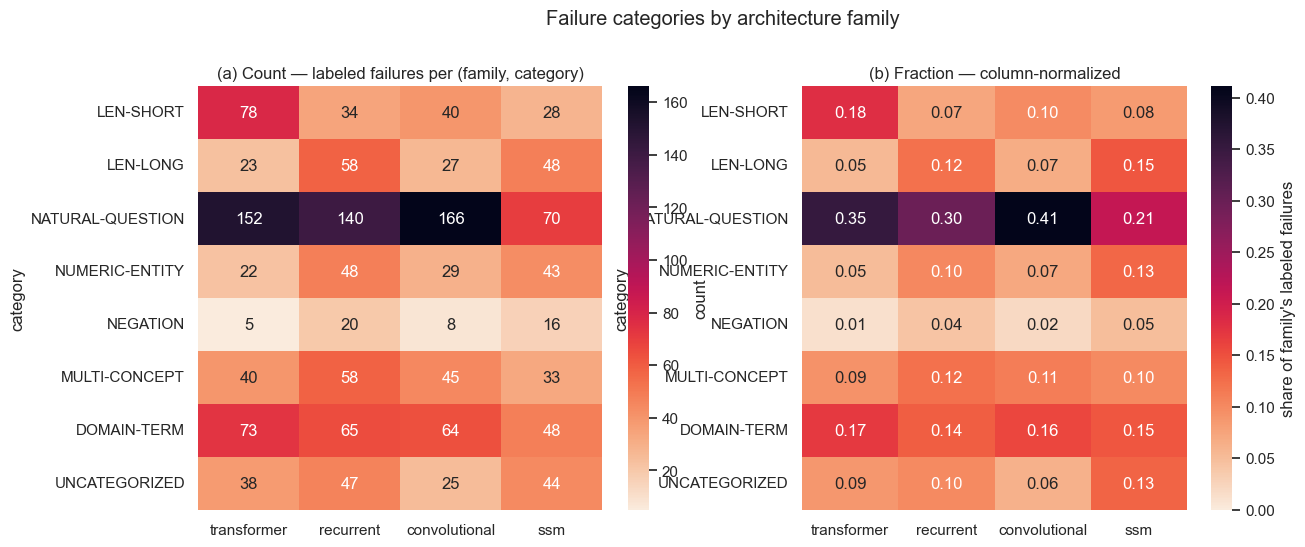

In [11]:
order = ["LEN-SHORT", "LEN-LONG", "NATURAL-QUESTION", "NUMERIC-ENTITY",
         "NEGATION", "MULTI-CONCEPT", "DOMAIN-TERM", "UNCATEGORIZED"]
pivot_ordered = pivot.reindex([c for c in order if c in pivot.index])
families = ["transformer", "recurrent", "convolutional", "ssm"]
pivot_ordered = pivot_ordered[families]
frac = pivot_ordered / pivot_ordered.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.05, 1]})
sns.heatmap(pivot_ordered, annot=True, fmt="d", cmap="rocket_r",
            cbar_kws={"label": "count"}, ax=axes[0])
axes[0].set_title("(a) Count — labeled failures per (family, category)")
sns.heatmap(frac, annot=True, fmt=".2f", cmap="rocket_r",
            vmin=0, vmax=frac.values.max(),
            cbar_kws={"label": "share of family's labeled failures"}, ax=axes[1])
axes[1].set_title("(b) Fraction — column-normalized")
fig.suptitle("Failure categories by architecture family", y=1.02)
plt.show()

## 7. Cross-encoder wins and losses

Universal wins (all 6 succeed) are small on FiQA — only 19 queries are
easy for every encoder. Universal losses (all 6 fail) make up 23.5% of
FiQA, bounding what any dense-retrieval fix can recover.

In [12]:
xsum = pd.read_csv(OUT / "cross_encoder_summary.csv", index_col=0)
xsum

,universal_wins,universal_losses,transformer_gap,unique_minilm-l6-v2,unique_bert-base,unique_gte-small,unique_lstm-retriever,unique_conv-retriever,unique_mamba-retriever-fs
nfcorpus,45,85,38,4,10,12,2,1,6
scifact,62,32,91,5,3,14,0,0,1
fiqa,19,152,235,22,21,36,4,1,4


The "transformer-gap" column is the most publishable number in the phase:
queries where *any* pre-trained transformer succeeds but *all three*
from-scratch encoders fail. 30–36% of FiQA/SciFact is in this set — that
is the concrete measure of where pre-training's value concentrates.

In [13]:
for ds in DEFAULT_DATASETS:
    sets = json.load(open(OUT / "cross_encoder_sets" / f"{ds}.json"))
    print(f"{ds:>9} transformer-gap queries: {sets['transformer_gap_queries']['n']}")

 nfcorpus transformer-gap queries: 38
  scifact transformer-gap queries: 91
     fiqa transformer-gap queries: 235


## 8. Six curated failure examples

See `../analysis/failure_examples.md` for the reviewer-visible version.
The notebook just surfaces the raw picks so the reader can verify.

In [14]:
examples_md = Path("../analysis/failure_examples.md").read_text()
print(examples_md[:4000])
print("...")

# Failure examples — Vitruvius Phase 6

Six characteristic failures, chosen to illustrate the phase's distinct findings. Each query text is verbatim from BEIR; doc IDs are from the Phase 3 / Phase 5 bench JSONs. Document titles and relevant-passage paraphrases are intentionally omitted — Phase 6 did not reload the BEIR corpora (see `experiments/phase6/SUMMARY.md`, Limitations). The analyst interpretations below are based solely on the query text, the qrels ID set, and the retrieved ID set.

## Example 1. CNN catastrophic failure on a long FiQA question

**Finding.** CNN's max-kernel receptive field (7 tokens) cannot span a 20+ token natural-language question; a pre-trained transformer of comparable size retrieves correctly. Directly supports the query-length-vs-nDCG plot.

**Query** (`fiqa:5380`, 23 WordPiece tokens): "Can somebody explain “leveraged debt investment positions” and “exposures” in this context for me, please?"

**Qrels.** 1 relevance-judged document(s). Relevant IDs (tri

## 9. Limitations reminder

- Failure threshold `nDCG@10 < 0.1` is a choice (documented in
  `experiments/phase6/SUMMARY.md`).
- Single labeler; no inter-annotator agreement.
- No corpus reload → `PARAPHRASE` / `AMBIGUOUS` / `MULTI-HOP` categories
  are out of scope.
- 3 BEIR subsets only.
- Sampling is stratified, not random; architecture × category pivot is
  descriptive of the sample, not an incidence rate over the whole frame.